# Prediction Model File

This file will utilize the insurance_data_cleaned.csv file to conduct prediction model. The goal is to compare different prediction models, and understand the most practical prediction model that could balance both interpretability and prediction accuracy.

## Reading in data & correlation plot

As the first step, we would investigate the scatterplot pairs across all variables within the data files, to see if there is any obvious trends and relationship between different variables. 

In [33]:
# Loading all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, accuracy_score, log_loss

# Importing warnings, suppresing all warnings
import warnings
warnings.filterwarnings('ignore')

# Setting the background of the plots to white
sns.set_style('whitegrid')

In [3]:
# Read in data 
df = pd.read_csv('insurance_data_cleaned.csv')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 185560 entries, 0 to 185559
Data columns (total 21 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   CHANNEL1                   185560 non-null  int64  
 1   CHANNEL2                   185560 non-null  int64  
 2   CHANNEL3                   185560 non-null  int64  
 3   ENTRY AGE                  185560 non-null  int64  
 4   SEX                        185560 non-null  str    
 5   POLICY TYPE 1              185560 non-null  int64  
 6   POLICY TYPE 2              185560 non-null  int64  
 7   POLICY TYPE 3              185560 non-null  str    
 8   PAYMENT MODE               185560 non-null  str    
 9   POLICY STATUS              185560 non-null  str    
 10  BENEFIT                    185560 non-null  float64
 11  NON LAPSE GUARANTEED       185560 non-null  str    
 12  SUBSTANDARD RISK           185560 non-null  float64
 13  NUMBER OF ADVANCE PREMIUM  185560 non-nu

### Checking with scatterplot between different variables available in the dataset

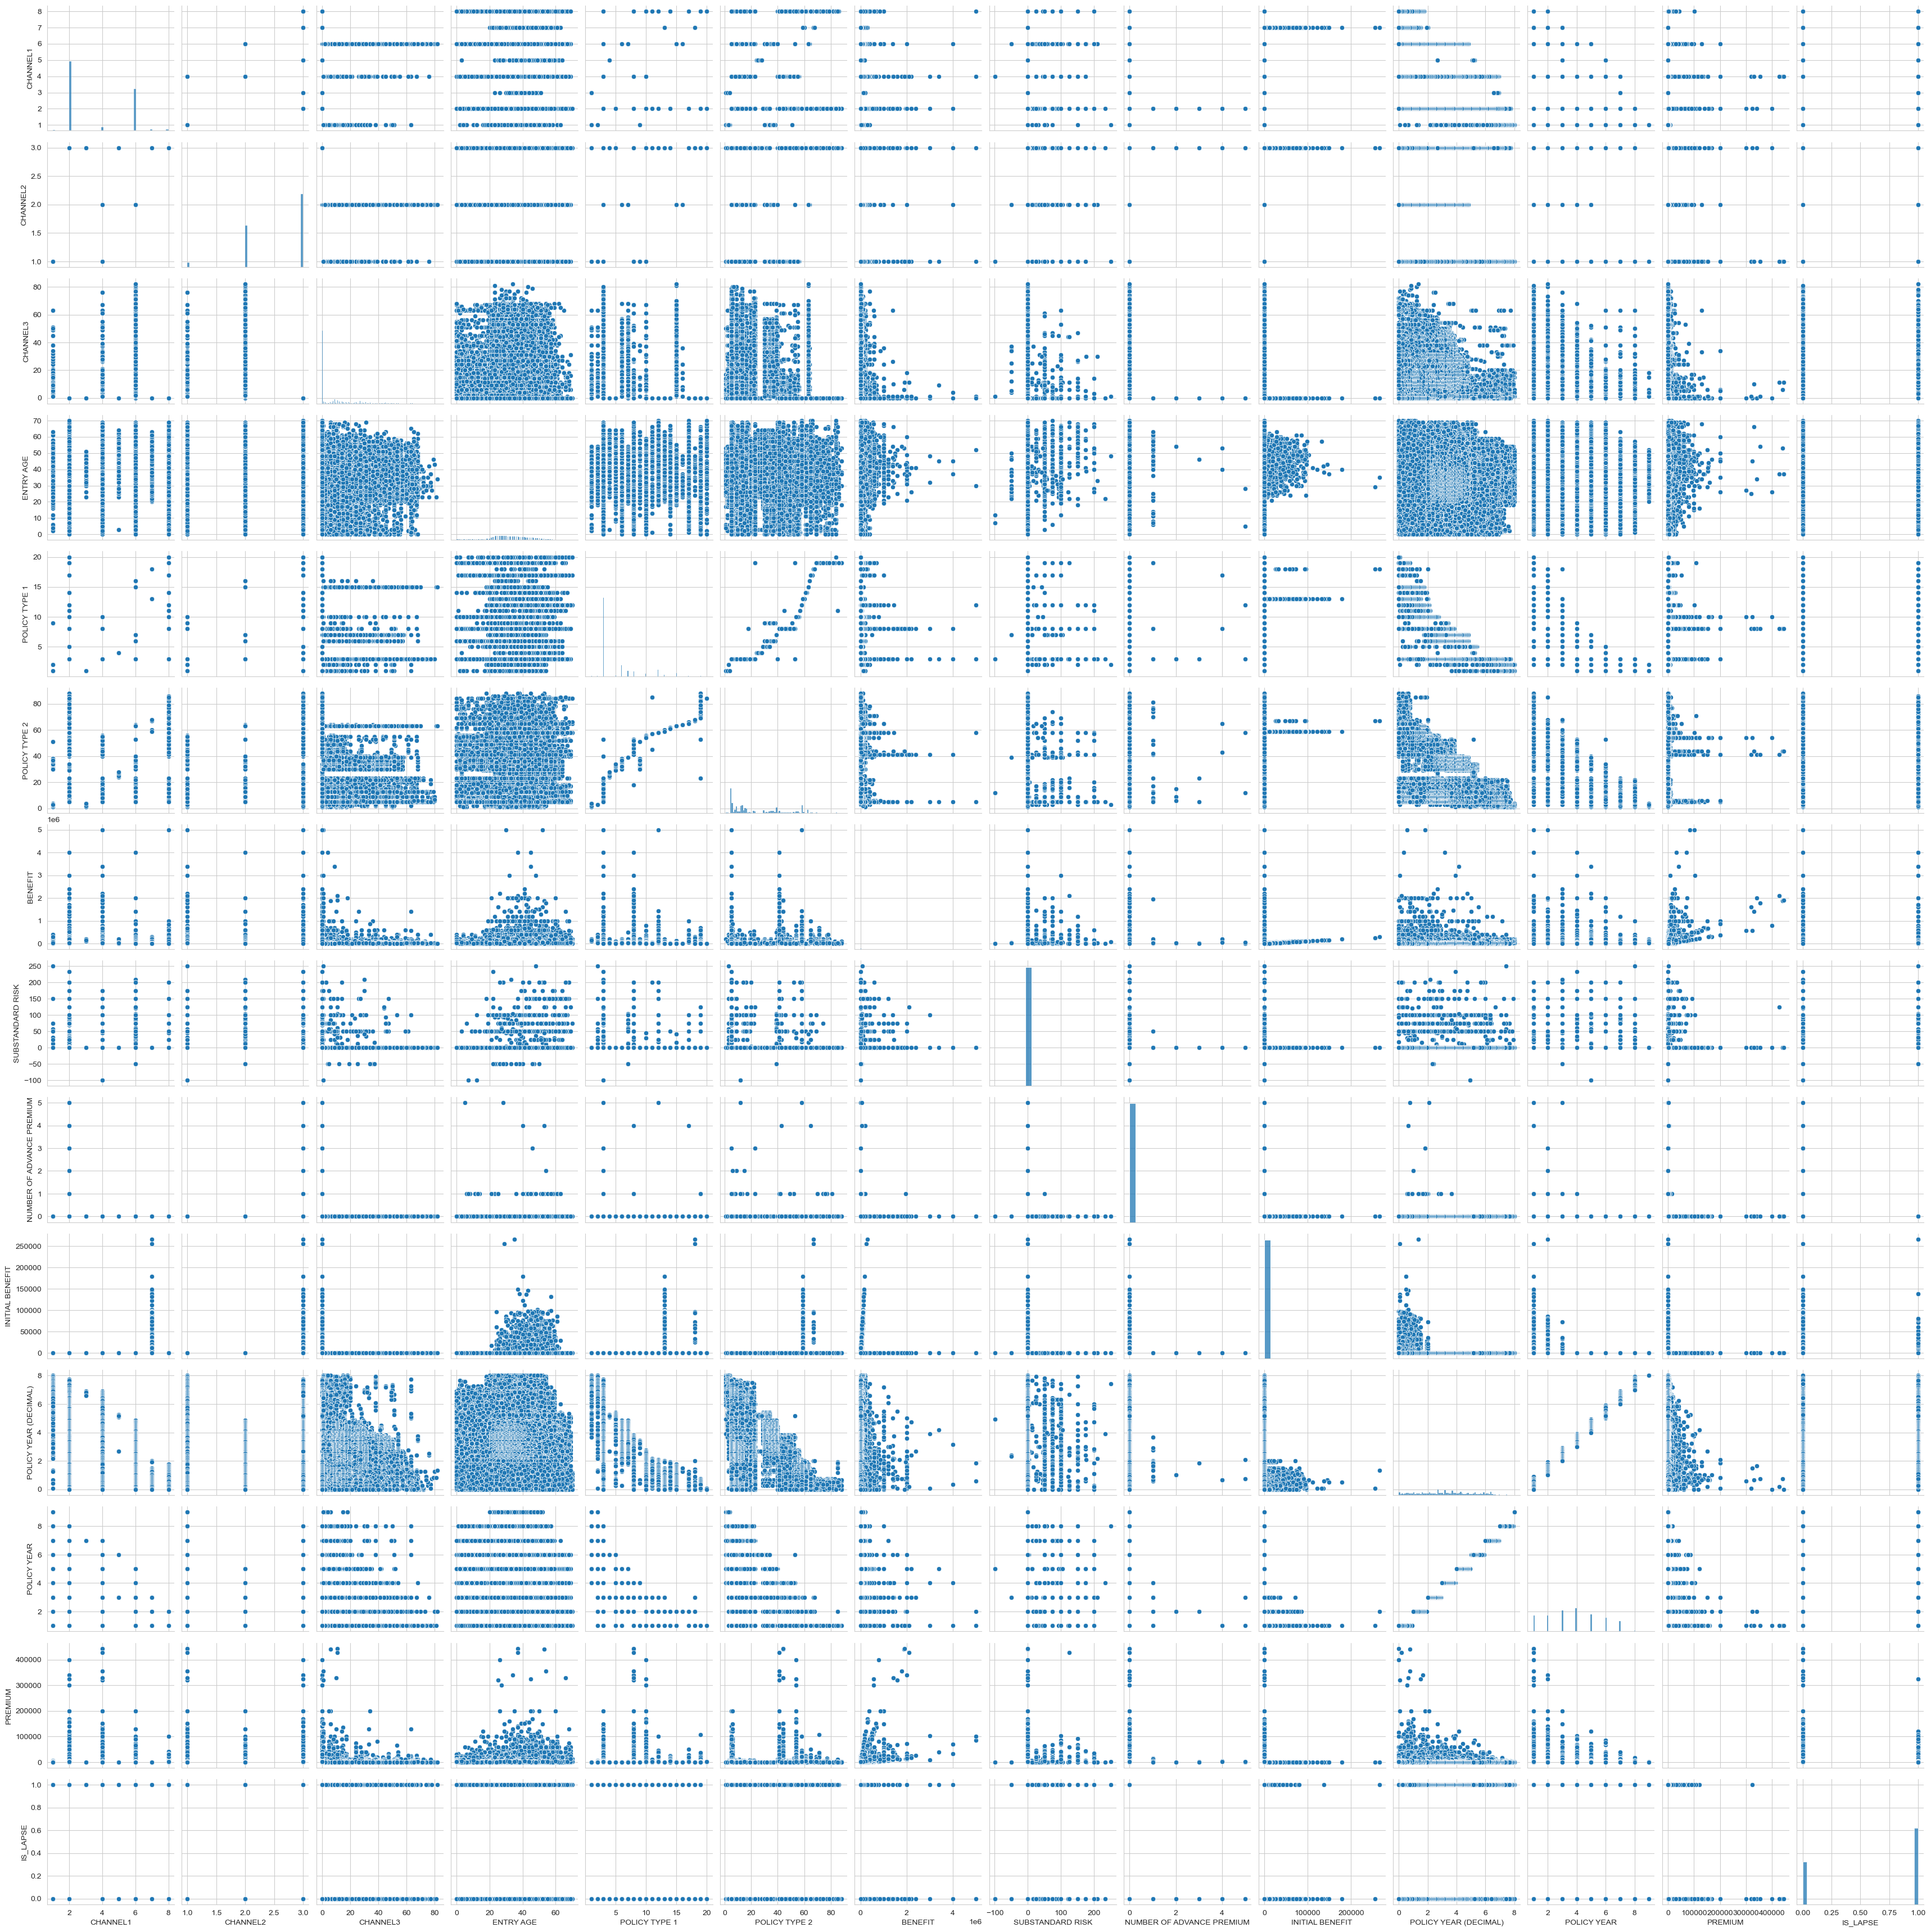

In [8]:
# Create a pairs scatterplot to visualize relationships between numeric features and the target

# 1. Use pairplot on the whole dataframe
# Python will automatically only plot the numeric columns (floats/ints)
sns.pairplot(df)

# 2. Display
plt.show()

### Processing data
Based on the plot above, we can see that there is a strong linear correlation between POLICY YEAR and POLICY YEAR (DECIMAL). We will drop the POLICY YEAR since it has the same information as the POLICY YEAR (DECIMAL), and including them will cause multicollinearity problem. 

We will also drop other variables which are not relevant to our analysis/cannot provide additional information to our prediction model. 

Since there is negative values for substandard risk, which is invalid values for risk, we will also drop those values.

In [6]:
# Dropping irrelevant columns
col_drop = ['POLICY STATUS', 'POLICY YEAR','ISSUE DATE']
df = df.drop(columns=col_drop)

In [7]:
# Dropping rows with substandard risk <0 
df = df.drop(df[df['SUBSTANDARD RISK'] < 0].index)

In [8]:
df.info()

<class 'pandas.DataFrame'>
Index: 185537 entries, 0 to 185559
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   CHANNEL1                   185537 non-null  int64  
 1   CHANNEL2                   185537 non-null  int64  
 2   CHANNEL3                   185537 non-null  int64  
 3   ENTRY AGE                  185537 non-null  int64  
 4   SEX                        185537 non-null  str    
 5   POLICY TYPE 1              185537 non-null  int64  
 6   POLICY TYPE 2              185537 non-null  int64  
 7   POLICY TYPE 3              185537 non-null  str    
 8   PAYMENT MODE               185537 non-null  str    
 9   BENEFIT                    185537 non-null  float64
 10  NON LAPSE GUARANTEED       185537 non-null  str    
 11  SUBSTANDARD RISK           185537 non-null  float64
 12  NUMBER OF ADVANCE PREMIUM  185537 non-null  int64  
 13  INITIAL BENEFIT            185537 non-null  f

In [ ]:
# Converting string variables to categorical variables (using dummies)
# Select Features (Defining Continuous vs Categorical for Box-Tidwell later)
continuous_features = ['CHANNEL1', 'CHANNEL2', 'CHANNEL3', 
                       'ENTRY AGE', 'POLICY TYPE 1', 'POLICY TYPE 2', 'SUBSTANDARD RISK',
                       'PREMIUM', 'BENEFIT', 'POLICY YEAR (DECIMAL)', 'NUMBER OF ADVANCE PREMIUM', 'INITIAL BENEFIT']
categorical_features = ['SEX', 'PAYMENT MODE','POLICY TYPE 3','NON LAPSE GUARANTEED', 'FULL BENEFIT?']

# 3. Handle Dummies (drop_first=True to avoid multicollinearity)
X = pd.get_dummies(df[continuous_features + categorical_features], drop_first=True).astype(float)
y = df['IS_LAPSE']

In [11]:
# Check the structure of feature set
X.info()

<class 'pandas.DataFrame'>
Index: 185537 entries, 0 to 185559
Data columns (total 25 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   CHANNEL1                             185537 non-null  float64
 1   CHANNEL2                             185537 non-null  float64
 2   CHANNEL3                             185537 non-null  float64
 3   ENTRY AGE                            185537 non-null  float64
 4   POLICY TYPE 1                        185537 non-null  float64
 5   POLICY TYPE 2                        185537 non-null  float64
 6   SUBSTANDARD RISK                     185537 non-null  float64
 7   PREMIUM                              185537 non-null  float64
 8   BENEFIT                              185537 non-null  float64
 9   POLICY YEAR (DECIMAL)                185537 non-null  float64
 10  NUMBER OF ADVANCE PREMIUM            185537 non-null  float64
 11  INITIAL BENEFIT              

### Data splitting

After we have complete some basic data processing, we move forward with splitting the data. We will first

(1) Split the data into training and testing set according to 85-15 ratio. The training set is used to train the model, whereas the testing set acts as unseen and unknown data, useful for our to test the out of sample performance of our model to ensure a more robust analysis. 

(2) Then, we will further split the training set into training and validation set, according to a 70-30 ratio. The training set is used to train the model, whereas the validation set is used to test the current model performance, assuming that the training set is the data we collected. 

In [12]:
# Splitting data
# First split: Separate the "Unseen" Test Set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)

# Second split: Split the remaining 85% into Train (70%) and Validation (30%)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.30, random_state=42, stratify=y_temp)

print(f"Data Split Complete:\nTrain: {X_train.shape[0]}\nVal: {X_val.shape[0]}\nTest: {X_test.shape[0]}")

Data Split Complete:
Train: 110394
Val: 47312
Test: 27831


### Checking Multicollinearity

Right now we have finished splitting the data. We will enter the next stage which is checking multicollinearity using Variance Inflation Factor (VIF). This method aims to discover any closely related variables, which might inflate the variance of our coefficients and make them unstable. Ideally, we hope our features are very uncorrelated betweene each other so each of them could provide unique and distinct information to predicting responses.

In [13]:
# We check this on the training set to avoid data leakage
def calculate_vif(X_df):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X_df.columns
    # Add constant for VIF calculation
    X_vif = sm.add_constant(X_df)
    vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(X_df.columns))]
    return vif_data

print("\n--- Variance Inflation Factor (VIF) ---")
print(calculate_vif(X_train))


--- Variance Inflation Factor (VIF) ---
                                Feature        VIF
0                              CHANNEL1   3.725534
1                              CHANNEL2   2.660883
2                              CHANNEL3   2.097090
3                             ENTRY AGE   1.041615
4                         POLICY TYPE 1  12.456862
5                         POLICY TYPE 2  11.458024
6                      SUBSTANDARD RISK   1.013779
7                               PREMIUM   1.291239
8                               BENEFIT   1.314604
9                 POLICY YEAR (DECIMAL)   1.677645
10            NUMBER OF ADVANCE PREMIUM   1.002580
11                      INITIAL BENEFIT   1.435222
12                                SEX_M   1.019232
13                 PAYMENT MODE_Monthly   1.695598
14                PAYMENT MODE_Quaterly   1.370997
15            PAYMENT MODE_Semiannually   1.188154
16          PAYMENT MODE_Single Premium   2.090058
17                      POLICY TYPE 3_B  

Criteria for VIF evaluation:

* VIF = 1: Not correlated.
* VIF 1–5: Moderately correlated.
* VIF > 10: Serious multicollinearity, requires correction

Based on the results above, we saw a large VIF for POLICY TYPE 1 and 2, indicating that there is a strong correlation between these two variables, and they likely contribute the same information to predicting the response. Since that's the case, we will drop POLICY TYPE 2. 

In addition, there is a high correlation between 2 levels, SUSPEND and NO NLG in the NON LAPSE GUARANTEED categories, indicating that both levels might be conveying the same information. Since they are both technically 'Inactive', we could group them under one categories - Inactive.

In [23]:
# Create the new 'Inactive' column by adding the two columns together
# (Since a row can only be one or the other, the sum will be 1 or 0)
for i in [X_train, X_val, X_test]:  
    i['NON LAPSE GUARANTEED_Inactive'] = i['NON LAPSE GUARANTEED_NO NLG'] + i['NON LAPSE GUARANTEED_NLG Suspend']

    # Now drop the old redundant columns and Policy Type 2
    cols_to_remove = [
        'NON LAPSE GUARANTEED_NO NLG', 
        'NON LAPSE GUARANTEED_NLG Suspend', 
        'POLICY TYPE 2'
    ]

    i.drop(columns=cols_to_remove, inplace=True)

KeyError: 'NON LAPSE GUARANTEED_NO NLG'

In [43]:
print("\n--- Variance Inflation Factor (VIF) ---")
print(calculate_vif(X_train))


--- Variance Inflation Factor (VIF) ---
                                Feature       VIF
0                              CHANNEL1  3.705999
1                              CHANNEL2  2.657003
2                              CHANNEL3  2.096641
3                             ENTRY AGE  1.040447
4                         POLICY TYPE 1  1.722340
5                      SUBSTANDARD RISK  1.013762
6                               PREMIUM  1.290985
7                               BENEFIT  1.313918
8                 POLICY YEAR (DECIMAL)  1.666661
9             NUMBER OF ADVANCE PREMIUM  1.002308
10                      INITIAL BENEFIT  1.435181
11                                SEX_M  1.019204
12                 PAYMENT MODE_Monthly  1.677896
13                PAYMENT MODE_Quaterly  1.364421
14            PAYMENT MODE_Semiannually  1.187014
15          PAYMENT MODE_Single Premium  2.079860
16                      POLICY TYPE 3_B  1.353163
17                      POLICY TYPE 3_C  1.490615
18       

In [29]:
continuous_features = ['CHANNEL1', 'CHANNEL2', 'CHANNEL3', 
                       'ENTRY AGE', 'POLICY TYPE 1', 'SUBSTANDARD RISK',
                       'PREMIUM', 'BENEFIT', 'POLICY YEAR (DECIMAL)', 'NUMBER OF ADVANCE PREMIUM', 'INITIAL BENEFIT']
categorical_features = ['SEX', 'PAYMENT MODE','POLICY TYPE 3','NON LAPSE GUARANTEED', 'FULL BENEFIT?']


## Logistics Regression

Before conducting logistic regression, we will first check the assumptions, which includes

(1) Binary Outcome (target is 0/1)
(2) Independence of errors: Assumed (unless policies are from the same household/group)
(3) Linearity of independent variables and log-odds: Check this via Box-Tidwell.

In [25]:
# Assumption checks for Assumption 1
y_train.value_counts(normalize=True)
# Yes, the first assumption is fulfilled.

IS_LAPSE
1    0.641828
0    0.358172
Name: proportion, dtype: float64

In [30]:
# Assumption checks for Assumption 3 - Box-Tidwell Test for Linearity of Logit

# Box-Tidwell checks if the relationship between continuous features and log-odds is linear
# This removes dummy variables which are often the cause of 'Singular Matrix'
X_bt_simple = X_train[continuous_features].copy()

for col in continuous_features:
    # Use a slightly larger constant if you have small values
    X_bt_simple[f'{col}_log'] = X_bt_simple[col] * np.log(X_bt_simple[col] + 1)

# 2. Add constant
X_bt_simple = sm.add_constant(X_bt_simple)

# 3. Fit ONLY these
try:
    bt_results = sm.Logit(y_train, X_bt_simple).fit(disp=0)
    print(bt_results.summary2().tables[1])

except Exception as e:
    print(f"Error: {e}")
    # If it still fails, check for constant columns
    print("\nColumn Variances (Should not be 0):")
    print(X_bt_simple.var())

                                      Coef.      Std.Err.          z  \
const                         -2.229045e+00  2.648137e-01  -8.417410   
CHANNEL1                      -1.974602e+00  1.635506e-01 -12.073340   
CHANNEL2                       4.359788e+00  3.421100e-01  12.743818   
CHANNEL3                       4.261492e-03  8.438829e-03   0.504986   
ENTRY AGE                      1.977211e-01  6.387204e-03  30.955822   
POLICY TYPE 1                 -1.791526e-01  2.782968e-02  -6.437465   
SUBSTANDARD RISK               2.520788e-03  1.502126e-02   0.167815   
PREMIUM                       -2.362514e-04  1.881666e-05 -12.555441   
BENEFIT                       -7.297100e-06  1.509194e-06  -4.835096   
POLICY YEAR (DECIMAL)          1.804792e+00  3.149722e-02  57.300059   
NUMBER OF ADVANCE PREMIUM     -2.866869e+01  3.061750e+04  -0.000936   
INITIAL BENEFIT               -5.781420e-04  7.332401e-05  -7.884757   
CHANNEL1_log                   7.539799e-01  6.516701e-02  11.56

In [31]:
bt_results.pvalues

const                             3.849003e-17
CHANNEL1                          1.460821e-33
CHANNEL2                          3.374656e-37
CHANNEL3                          6.135685e-01
ENTRY AGE                        2.121297e-210
POLICY TYPE 1                     1.214854e-10
SUBSTANDARD RISK                  8.667291e-01
PREMIUM                           3.711074e-36
BENEFIT                           1.330811e-06
POLICY YEAR (DECIMAL)             0.000000e+00
NUMBER OF ADVANCE PREMIUM         9.992529e-01
INITIAL BENEFIT                   3.151480e-15
CHANNEL1_log                      5.850719e-31
CHANNEL2_log                      1.962869e-36
CHANNEL3_log                      5.732526e-01
ENTRY AGE_log                    1.126307e-225
POLICY TYPE 1_log                 5.795283e-08
SUBSTANDARD RISK_log              7.382364e-01
PREMIUM_log                       5.892960e-34
BENEFIT_log                       1.066551e-05
POLICY YEAR (DECIMAL)_log         0.000000e+00
NUMBER OF ADV

We conduct Box-Tidwell test, with the null hypothesis H0 of linear relationships between the continuous features and the log-odds. Based on the result above, the p-values of most of the log variables is very small, providing sufficient evidence that most of the features and log-odds are not linearly related. 

Even though this violates logistic regression, we can still conduct this test as our basic baseline to see the performance. 

In [38]:
# Conducting logistics regression

# 1. Scale continuous data (Crucial for interpretation)
scaler = StandardScaler()
# Note: We fit on Train and transform Val/Test to prevent leakage
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[continuous_features] = scaler.fit_transform(X_train[continuous_features])
X_val_scaled[continuous_features] = scaler.transform(X_val[continuous_features])
X_test_scaled[continuous_features] = scaler.transform(X_test[continuous_features])

# 1. Fit the model (as you did)
X_train_final = sm.add_constant(X_train_scaled)
logit_model = sm.Logit(y_train, X_train_final).fit(maxiter=1000)  # Increased maxiter to ensure convergence

# 2. Prepare Validation and Test sets (must add constant to these too!)
X_val_final = sm.add_constant(X_val_scaled)
X_test_final = sm.add_constant(X_test_scaled)

# 3. Generate Predictions (Probabilities)
# .predict() in statsmodels gives the probability (0.0 to 1.0)
y_prob_train = logit_model.predict(X_train_final)
y_prob_val = logit_model.predict(X_val_final)
y_prob_test = logit_model.predict(X_test_final)

# 4. Calculate RMSE
# RMSE = sqrt(Mean Squared Error)
rmse_train = np.sqrt(mean_squared_error(y_train, y_prob_train))
rmse_val = np.sqrt(mean_squared_error(y_val, y_prob_val))
rmse_test = np.sqrt(mean_squared_error(y_test, y_prob_test))

# 5. Calculate Log-Loss (The "True" Logistic metric)
logloss_test = log_loss(y_test, y_prob_test)

print(f"--- Performance Metrics ---")
print(f"RMSE Train:      {rmse_train:.4f}")
print(f"RMSE Validation: {rmse_val:.4f}")
print(f"RMSE Test:       {rmse_test:.4f}")
print(f"Log-Loss Test:   {logloss_test:.4f}")

# 6. Check for Overfitting
if rmse_val > rmse_train * 1.1:
    print("\nWarning: Potential Overfitting! Validation error is significantly higher than Train error.")
else:
    print("\nModel stability looks good: Train and Validation errors are close.")

         Current function value: 0.539773
         Iterations: 1000
--- Performance Metrics ---
RMSE Train:      0.4240
RMSE Validation: 0.4242
RMSE Test:       0.4257
Log-Loss Test:   0.5442

Model stability looks good: Train and Validation errors are close.


In [44]:
y_prob_train

25865     0.701851
106904    0.807508
90353     0.830995
25877     0.766458
163286    0.658127
            ...   
41645     0.818623
174233    0.441888
36254     0.486542
62927     0.833959
154086    0.410132
Length: 110394, dtype: float64

In [39]:
logit_model.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                                      Results: Logit
==========================================================================================
Model:                      Logit                    Method:                   MLE        
Dependent Variable:         IS_LAPSE                 Pseudo R-squared:         0.173      
Date:                       2026-03-11 14:56         AIC:                      119223.4685
No. Observations:           110394                   BIC:                      119454.1520
Df Model:                   23                       Log-Likelihood:           -59588.    
Df Residuals:               110370                   LL-Null:                  -72017.    
Converged:                  0.0000                   LLR p-value:              0.0000     
No. Iterations:             1000.0000                Scale:                    1.0000     
------------------------------------------------------------------------------------------
                                     Coef.   Std.Err.    z     P>|z|    [0.025     0.975] 
------------------------------------------------------------------------------------------
const                                0.0013   28.8048   0.0000 1.0000   -56.4551   56.4577
CHANNEL1                            -0.0154    0.0136  -1.1272 0.2596    -0.0421    0.0114
CHANNEL2                             0.1028    0.0120   8.6029 0.0000     0.0794    0.1263
CHANNEL3                             0.0015    0.0096   0.1516 0.8795    -0.0174    0.0203
ENTRY AGE                           -0.0724    0.0073  -9.8647 0.0000    -0.0867   -0.0580
POLICY TYPE 1                       -0.1791    0.0087 -20.6336 0.0000    -0.1961   -0.1621
SUBSTANDARD RISK                    -0.0188    0.0073  -2.5900 0.0096    -0.0331   -0.0046
PREMIUM                             -0.1123    0.0158  -7.0931 0.0000    -0.1434   -0.0813
BENEFIT                             -0.0427    0.0107  -3.9813 0.0001    -0.0637   -0.0217
POLICY YEAR (DECIMAL)                0.6975    0.0093  75.0866 0.0000     0.6793    0.7157
NUMBER OF ADVANCE PREMIUM           -0.7454 1592.0051  -0.0005 0.9996 -3121.0181 3119.5273
INITIAL BENEFIT                     -0.0560    0.0286  -1.9597 0.0500    -0.1119    0.0000
SEX_M                                0.0489    0.0145   3.3782 0.0007     0.0205    0.0773
PAYMENT MODE_Monthly                 1.1705    0.0213  55.0235 0.0000     1.1288    1.2122
PAYMENT MODE_Quaterly                1.0042    0.0358  28.0656 0.0000     0.9341    1.0744
PAYMENT MODE_Semiannually            0.7842    0.0453  17.3055 0.0000     0.6954    0.8731
PAYMENT MODE_Single Premium         -1.1110    0.1975  -5.6250 0.0000    -1.4982   -0.7239
POLICY TYPE 3_B                     -1.7297    0.0692 -24.9776 0.0000    -1.8654   -1.5940
POLICY TYPE 3_C                     -0.0823    0.0178  -4.6177 0.0000    -0.1172   -0.0473
POLICY TYPE 3_D                     -0.4442    0.0262 -16.9577 0.0000    -0.4956   -0.3929
POLICY TYPE 3_E                      0.8984    0.0323  27.8077 0.0000     0.8351    0.9617
NON LAPSE GUARANTEED_NLG Not Active -2.4864    0.2258 -11.0115 0.0000    -2.9290   -2.0439
FULL BENEFIT?_Y                     -0.9438    0.3594  -2.6260 0.0086    -1.6482   -0.2394
NON LAPSE GUARANTEED_Inactive       -0.2919    0.2066  -1.4132 0.1576    -0.6968    0.1129
==========================================================================================

"""

In [42]:
X.columns

Index(['CHANNEL1', 'CHANNEL2', 'CHANNEL3', 'ENTRY AGE', 'POLICY TYPE 1',
       'SUBSTANDARD RISK', 'PREMIUM', 'BENEFIT', 'POLICY YEAR (DECIMAL)',
       'NUMBER OF ADVANCE PREMIUM', 'INITIAL BENEFIT', 'SEX_M',
       'PAYMENT MODE_Monthly', 'PAYMENT MODE_Quaterly',
       'PAYMENT MODE_Semiannually', 'PAYMENT MODE_Single Premium',
       'POLICY TYPE 3_B', 'POLICY TYPE 3_C', 'POLICY TYPE 3_D',
       'POLICY TYPE 3_E', 'NON LAPSE GUARANTEED_NLG Not Active',
       'FULL BENEFIT?_Y', 'NON LAPSE GUARANTEED_Inactive'],
      dtype='str')